# Chapter 2 — Framework 2: Reference subset validation by RDA resampling

This notebook validates whether the selected least-stressed/reference subset behaves differently from random site subsets of the same size.

The execution structure is:

```text
Inputs → Definition Corner → Process → Outputs → Visualization → Optional extension
```

The helper functions are kept inside this notebook, but they are grouped in the **Definition Corner** so that the visible execution cells remain readable.

# Inputs

Load the site metadata, taxa matrix, and Framework 1 chemical-stressor artifact.

In [100]:
from pathlib import Path
import pandas as pd

# Repository paths
METADATA_DIR = Path("../data")
ARTIFACT_DIR = Path("../artifacts")
RESULTS_DIR = Path("../results")
FIGURE_DIR = Path("../figures")

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Load taxa matrix
site_info = pd.read_excel(METADATA_DIR / "Info.xlsx")
site_ids = site_info["Integrated Code"].reset_index(drop=True).rename("Integrated Code")

T = pd.read_excel(METADATA_DIR / "T.xlsx").reset_index(drop=True)
T_with_site_id = pd.concat([site_ids, T], axis=1)

# Load the artifact A1 - stressor-score matrix S_c
S_c = pd.read_excel(ARTIFACT_DIR / "A1_stressors_and_scores.xlsx").reset_index(drop=True)

print(f"Loaded taxa matrix T: {T_with_site_id.shape[0]} sites × {T_with_site_id.shape[1] - 1} taxa variables")
display(T_with_site_id.head())

print(f"Loaded stressor-score matrix S_c: {S_c.shape[0]} sites × {S_c.shape[1] - 1} variables")
display(S_c.head())

Loaded taxa matrix T: 310 sites × 16 taxa variables


,Integrated Code,Oligochaeta,Nematoda,Chironomidae,Ceratopogonidae,Hexagenia,Caenis,Hydropsychidae,Other Trichoptera,Amphipoda,Dreissena,Acari,Hydrozoa,Hirudinea,Turbellaria,Gastropoda,Sphaeriidae
0,DR-02,2.269984,0.563546,1.655598,0.0,0.309116,0.000000,2.438439,0.0,4.529993,6.082918,0.000000,0.00000,0.00000,0.0,0.000000,0.0
1,DR-03,3.808504,3.512091,6.242625,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.801982,0.801982,0.00000,0.00000,0.0,0.456015,0.0
2,DR-04,4.820163,5.519382,4.733464,0.0,0.815949,0.000000,0.000000,0.0,0.000000,0.172158,1.010022,0.00000,0.00000,0.0,0.464907,0.0
3,DR-06,1.449187,0.181596,2.271083,0.0,0.999573,0.033941,0.000000,0.0,1.840242,6.475708,0.000000,1.82093,0.23027,0.0,0.000000,0.0
4,DR-07,1.082238,0.246371,2.499653,0.0,0.128438,0.000000,0.128438,0.0,4.224262,6.266368,0.000000,0.00000,0.00000,0.0,0.246371,0.0


Loaded stressor-score matrix S_c: 310 sites × 6 variables


,Integrated Code,PC1,PC3,PC4,PC5,SumRel,MaxRel
0,DR-02,-3.576446,2.096010,-0.392204,0.327409,-1.545231,2.096010
1,DR-03,-9.212448,-3.485213,-1.269014,0.152120,-13.814555,0.152120
2,DR-04,-8.313318,0.509110,-1.422312,-0.048742,-9.275262,0.509110
3,DR-06,7.727415,3.855054,0.583084,3.001895,15.167448,7.727415
4,DR-07,-6.315431,1.386617,-1.047327,0.575785,-5.400357,1.386617


## Analysis parameters

These parameters control the reference subset, random-subset background, and RDA permutation test.

In [101]:
SITE_ID_COLUMN = "Integrated Code"

# PC2 is intentionally excluded because Framework 1 interpreted it as a natural geochemical axis,
# not a direct contamination-stress axis.
STRESSOR_COLUMNS = ["PC1", "PC3", "PC4", "PC5"]
SCORE_COLUMN = "SumRel"
SELECTED_COLUMNS = STRESSOR_COLUMNS + [SCORE_COLUMN]
TAXA_COLUMNS = T.columns.tolist()

# Main reference-subset validation setting
M_REFERENCE = 62
N_RANDOM_SUBSETS = 1000
PERMUTATIONS = 999
RANDOM_STATE = 42

print("Framework 2 parameter setting")
print(f"Reference subset size m: {M_REFERENCE}")
print(f"Number of random subsets B: {N_RANDOM_SUBSETS}")
print(f"RDA permutations: {PERMUTATIONS}")
print(f"Stressor predictors: {STRESSOR_COLUMNS}")
print(f"Ranking score: {SCORE_COLUMN}")

Framework 2 parameter setting
Reference subset size m: 62
Number of random subsets B: 1000
RDA permutations: 999
Stressor predictors: ['PC1', 'PC3', 'PC4', 'PC5']
Ranking score: SumRel


# Definition Corner

The following cells define reusable tools used by the visible workflow below. They can be collapsed or hidden during reading.

In [102]:
import numpy as np


def validate_required_columns(df: pd.DataFrame, required_columns, table_name: str = "dataframe") -> None:
    missing_columns = [column for column in required_columns if column not in df.columns]
    if missing_columns:
        raise KeyError(f"{table_name} is missing required columns: {missing_columns}")


def z_score_standardizer(df: pd.DataFrame, numeric_columns=None, ddof: int = 0) -> pd.DataFrame:
    """Apply column-wise z-score standardization to numeric columns."""
    standardized = df.copy()
    if numeric_columns is None:
        numeric_columns = standardized.select_dtypes(include="number").columns.tolist()

    validate_required_columns(standardized, numeric_columns, table_name="standardization input")

    numeric_frame = standardized[numeric_columns].astype(float)
    means = numeric_frame.mean(axis=0)
    stds = numeric_frame.std(axis=0, ddof=ddof).replace(0, np.nan)
    standardized[numeric_columns] = ((numeric_frame - means) / stds).fillna(0.0)
    return standardized


def select_least_stressed_sites(
    df: pd.DataFrame,
    score_column: str,
    m: int,
    site_id_column: str = "Integrated Code",
) -> pd.Series:
    """Return the IDs of the m least-contaminated sites according to a score column."""
    validate_required_columns(df, [site_id_column, score_column], table_name="stressor-score table")
    if m <= 0:
        raise ValueError("m must be positive.")
    if m > len(df):
        raise ValueError("m cannot exceed the number of available sites.")

    ranked = df[[site_id_column, score_column]].sort_values(
        by=score_column,
        ascending=True,
        kind="mergesort",
    )
    return ranked.head(m)[site_id_column].reset_index(drop=True)


def sample_random_site_subsets(site_ids, m: int, B: int, random_state=None) -> list[list]:
    """Sample B random subsets of size m without replacement within each subset."""
    site_index = pd.Index(site_ids).dropna().unique()
    if m <= 0 or B <= 0:
        raise ValueError("m and B must be positive.")
    if m > len(site_index):
        raise ValueError("m cannot exceed the number of available sites.")

    rng = np.random.default_rng(seed=random_state)
    return [
        site_index[rng.choice(len(site_index), size=m, replace=False)].tolist()
        for _ in range(B)
    ]


def slice_matrix_by_site_ids(
    df: pd.DataFrame,
    site_ids,
    site_id_column: str = "Integrated Code",
    value_columns=None,
    keep_site_id: bool = False,
) -> pd.DataFrame:
    """Slice rows by requested site-ID order and optionally keep only selected value columns."""
    validate_required_columns(df, [site_id_column], table_name="site-indexed table")

    if value_columns is None:
        working_columns = df.columns.tolist()
    else:
        validate_required_columns(df, value_columns, table_name="site-indexed table")
        working_columns = [site_id_column, *value_columns]

    indexed = df[working_columns].drop_duplicates(subset=site_id_column).set_index(site_id_column)
    requested_site_ids = pd.Index(site_ids)
    missing_site_ids = requested_site_ids.difference(indexed.index)
    if not missing_site_ids.empty:
        raise KeyError(f"Site IDs not found in dataframe: {missing_site_ids.tolist()[:10]}")

    sliced = indexed.loc[requested_site_ids]
    if keep_site_id:
        return sliced.reset_index()
    return sliced.reset_index(drop=True)


def materialize_subset_matrices(
    site_id_sets,
    stressor_table_z: pd.DataFrame,
    taxa_table: pd.DataFrame,
    selected_columns,
    taxa_columns,
    site_id_column: str,
) -> tuple[list[pd.DataFrame], list[pd.DataFrame]]:
    """Create aligned stressor and taxa matrices for each site-ID set."""
    S_sets = [
        slice_matrix_by_site_ids(
            stressor_table_z,
            site_ids=site_id_set,
            site_id_column=site_id_column,
            value_columns=selected_columns,
        )
        for site_id_set in site_id_sets
    ]

    T_sets = [
        slice_matrix_by_site_ids(
            taxa_table,
            site_ids=site_id_set,
            site_id_column=site_id_column,
            value_columns=taxa_columns,
        )
        for site_id_set in site_id_sets
    ]

    return S_sets, T_sets

In [103]:
from time import perf_counter
from rpy2 import robjects
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import PackageNotInstalledError, importr


def initialize_vegan_rda_runner():
    """Initialize the R-side vegan RDA runner."""
    try:
        importr("vegan")
    except PackageNotInstalledError as exc:
        raise ImportError(
            "R package 'vegan' is required for the RDA step. "
            "Install it in the active R environment and rerun this notebook."
        ) from exc

    return robjects.r(
        """
        function(taxa_df, predictor_df, permutations) {
          taxa_df <- as.data.frame(taxa_df)
          predictor_df <- as.data.frame(predictor_df)

          fit <- vegan::rda(taxa_df, predictor_df)
          adj_r2 <- vegan::RsquareAdj(fit)$adj.r.squared
          perm <- anova.cca(fit, permutations = permutations)

          data.frame(
            adj_r_squared = as.numeric(adj_r2),
            permutation_f = as.numeric(perm$F[1]),
            p_value = as.numeric(perm$`Pr(>F)`[1])
          )
        }
        """
    )


RDA_SUMMARY_RUNNER = initialize_vegan_rda_runner()


def run_rda_model(taxa_df: pd.DataFrame, predictor_df: pd.DataFrame, permutations: int = 999) -> dict:
    """Run vegan::rda and return adjusted R², permutation F, and p-value."""
    taxa_numeric = taxa_df.apply(pd.to_numeric, errors="raise")
    predictor_numeric = predictor_df.apply(pd.to_numeric, errors="raise")

    with localconverter(robjects.default_converter + pandas2ri.converter):
        summary_r = RDA_SUMMARY_RUNNER(taxa_numeric, predictor_numeric, int(permutations))
        summary_df = robjects.conversion.rpy2py(summary_r)

    return summary_df.iloc[0].to_dict()


def summarize_subset_rda(
    subset_id: str,
    subset_type: str,
    subset_site_ids,
    taxa_df: pd.DataFrame,
    descriptor_df: pd.DataFrame,
    score_lookup: pd.Series,
    m: int,
    stressor_columns,
    permutations: int = 999,
) -> dict:
    """Run one stressor-based RDA and summarize one subset."""
    if len(taxa_df) != len(descriptor_df):
        raise ValueError("Taxa and descriptor subsets must have the same number of rows.")
    if len(subset_site_ids) != len(taxa_df):
        raise ValueError("Subset site IDs must align with the taxa and descriptor subsets.")

    stressor_summary = run_rda_model(
        taxa_df=taxa_df,
        predictor_df=descriptor_df[stressor_columns],
        permutations=permutations,
    )

    average_c = float(score_lookup.loc[list(subset_site_ids)].mean())

    return {
        "subset_id": subset_id,
        "subset_type": subset_type,
        "m": int(m),
        "adj_R2_str": float(stressor_summary["adj_r_squared"]),
        "permutation_F_stressor": float(stressor_summary["permutation_f"]),
        "p_value_stressor": float(stressor_summary["p_value"]),
        "average_c": average_c,
    }


def run_reference_vs_random_rda(
    least_site_ids,
    random_site_id_sets,
    T_ref: pd.DataFrame,
    S_ref: pd.DataFrame,
    T_randoms,
    S_randoms,
    score_lookup: pd.Series,
    m: int,
    stressor_columns,
    permutations: int,
    random_state: int,
) -> pd.DataFrame:
    """Run the reference subset and all random-subset RDA summaries."""
    robjects.r["set.seed"](int(random_state))

    subset_summaries = []
    start_time = perf_counter()

    subset_summaries.append(
        summarize_subset_rda(
            subset_id="ref",
            subset_type="least_ranked",
            subset_site_ids=least_site_ids.tolist(),
            taxa_df=T_ref,
            descriptor_df=S_ref,
            score_lookup=score_lookup,
            m=m,
            stressor_columns=stressor_columns,
            permutations=permutations,
        )
    )

    for subset_index, (site_id_set, T_set, S_set) in enumerate(
        zip(random_site_id_sets, T_randoms, S_randoms),
        start=1,
    ):
        subset_summaries.append(
            summarize_subset_rda(
                subset_id=f"random_{subset_index:04d}",
                subset_type="random",
                subset_site_ids=site_id_set,
                taxa_df=T_set,
                descriptor_df=S_set,
                score_lookup=score_lookup,
                m=m,
                stressor_columns=stressor_columns,
                permutations=permutations,
            )
        )

        if subset_index % 100 == 0:
            elapsed_seconds = perf_counter() - start_time
            print(f"Processed {subset_index} random subsets in {elapsed_seconds:.1f}s")

    rda_results = pd.DataFrame(subset_summaries)
    elapsed_seconds = perf_counter() - start_time
    print(f"Completed {len(rda_results)} subset summaries in {elapsed_seconds:.1f}s")
    return rda_results

In [104]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


def set_plot_theme() -> None:
    plt.style.use("seaborn-v0_8-white")
    plt.rcParams.update({
        "axes.edgecolor": "#111111",
        "axes.grid": False,
        "axes.linewidth": 1.2,
        "axes.labelsize": 18,
        "axes.titlesize": 20,
        "figure.facecolor": "white",
        "font.size": 12,
        "legend.fontsize": 13,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    })


def build_density_curve(values, grid_size: int = 512, x_bounds=None):
    values = np.asarray(values, dtype=float)
    value_min = float(values.min())
    value_max = float(values.max())

    if np.isclose(value_min, value_max):
        padding = max(abs(value_min) * 0.1, 1e-6)
        left = value_min - padding
        right = value_max + padding
    else:
        padding = (value_max - value_min) * 0.12
        left = value_min - padding
        right = value_max + padding

    if x_bounds is not None:
        left = max(left, x_bounds[0])
        right = min(right, x_bounds[1])

    grid = np.linspace(left, right, grid_size)
    density = gaussian_kde(values)(grid)
    return grid, density


def add_sliding_contamination_axis(
    ax,
    x_values,
    contamination_values,
    percentile_step: int = 5,
    half_window: float = 2.5,
    guide_color: str = "#d1d5db",
    guide_alpha: float = 0.7,
):
    x_values = np.asarray(x_values, dtype=float)
    contamination_values = np.asarray(contamination_values, dtype=float)

    sort_order = np.argsort(x_values)
    x_sorted = x_values[sort_order]
    contamination_sorted = contamination_values[sort_order]
    n_values = len(x_sorted)

    percentile_centers = np.arange(percentile_step, 100, percentile_step)
    tick_positions = np.quantile(x_sorted, percentile_centers / 100.0)
    tick_labels = []

    for center in percentile_centers:
        lower_fraction = max(0.0, (center - half_window) / 100.0)
        upper_fraction = min(1.0, (center + half_window) / 100.0)
        start_index = int(np.floor(lower_fraction * n_values))
        end_index = int(np.ceil(upper_fraction * n_values))
        if end_index <= start_index:
            end_index = min(n_values, start_index + 1)

        window_mean = float(contamination_sorted[start_index:end_index].mean())
        tick_labels.append(f"{window_mean:.2f}")

    for tick_position in tick_positions:
        ax.axvline(
            tick_position,
            color=guide_color,
            linewidth=1.0,
            alpha=guide_alpha,
            zorder=0,
        )

    top_ax = ax.twiny()
    top_ax.set_xlim(ax.get_xlim())
    top_ax.set_xticks(tick_positions)
    top_ax.set_xticklabels(tick_labels)
    for tick_label in top_ax.get_xticklabels():
        tick_label.set_rotation(45)
        tick_label.set_ha("left")
        tick_label.set_rotation_mode("anchor")

    top_ax.set_xlabel(
        r"Sliding-window mean subset contamination score ($\bar{c}$)",
        labelpad=10,
        fontsize=15,
    )
    top_ax.tick_params(axis="x", labelsize=9, pad=3)
    top_ax.spines["bottom"].set_visible(False)
    top_ax.spines["top"].set_linewidth(1.4)
    top_ax.spines["left"].set_visible(False)
    top_ax.spines["right"].set_visible(False)
    return top_ax


def plot_empirical_distribution(
    random_values,
    reference_value: float,
    x_label: str,
    title: str,
    curve_color: str = "#ff7f0e",
    fill_color: str = "#fde68a",
    reference_color: str = "#f4b400",
    x_bounds=None,
    top_axis_mode=None,
    top_axis_values=None,
    output_path: Path | None = None,
):
    random_values = np.asarray(random_values, dtype=float)
    grid, density = build_density_curve(random_values, x_bounds=x_bounds)
    reference_density = float(np.interp(reference_value, grid, density))
    percentile = float((random_values <= reference_value).mean() * 100.0)

    fig, ax = plt.subplots(figsize=(12.5, 7.2), dpi=160)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.fill_between(grid, density, color=fill_color, alpha=0.45, label="Random subsets density", zorder=1)
    ax.plot(grid, density, color=curve_color, linewidth=3.0, label="Smoothed density", zorder=2)

    rug_y = np.full_like(random_values, -density.max() * 0.015)
    ax.scatter(random_values, rug_y, marker="|", s=150, color=curve_color, alpha=0.18, clip_on=False, zorder=0)

    ax.axvline(reference_value, color="#111111", linestyle="--", linewidth=2.0, label="Reference subset value", zorder=3)
    ax.scatter([reference_value], [reference_density], s=180, color=reference_color, edgecolor="#111111", linewidth=1.0, zorder=4)

    annotation_text = f"Reference = {reference_value:.4f}\nPercentile = {percentile:.1f}"
    ax.annotate(
        annotation_text,
        xy=(reference_value, reference_density),
        xytext=(14, 16),
        textcoords="offset points",
        fontsize=12,
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#d1d5db", "alpha": 0.96},
        arrowprops={"arrowstyle": "->", "color": "#111111", "lw": 1.1},
    )

    ax.set_title(title, pad=18)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Empirical Probability Density")
    ax.grid(False)
    ax.legend(loc="upper right", frameon=True, facecolor="white")
    ax.set_ylim(bottom=-density.max() * 0.04)

    if x_bounds is not None:
        ax.set_xlim(*x_bounds)

    if top_axis_mode == "sliding_contamination":
        if top_axis_values is None:
            raise ValueError("top_axis_values must be provided for sliding_contamination mode.")
        add_sliding_contamination_axis(ax, x_values=random_values, contamination_values=top_axis_values)

    fig.tight_layout()
    if output_path is not None:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig, ax


def summarize_empirical_distributions(rda_results: pd.DataFrame) -> pd.DataFrame:
    random_results = rda_results.loc[rda_results["subset_type"] == "random"].copy()
    reference_result = rda_results.loc[rda_results["subset_type"] == "least_ranked"].iloc[0]

    rows = []
    for metric_name in ["adj_R2_str", "p_value_stressor"]:
        rows.append({
            "case": "4 retained stressors only",
            "metric": metric_name,
            "reference_value": float(reference_result[metric_name]),
            "random_mean": float(random_results[metric_name].mean()),
            "random_median": float(random_results[metric_name].median()),
            "reference_percentile": float((random_results[metric_name] <= reference_result[metric_name]).mean() * 100.0),
        })
    return pd.DataFrame(rows)

In [105]:
def run_ranked_subset_rda_for_m(
    m_value: int,
    B_value: int,
    permutations_value: int,
    base_seed: int,
    stressor_table: pd.DataFrame,
    stressor_table_z: pd.DataFrame,
    taxa_table: pd.DataFrame,
    score_lookup: pd.Series,
):
    """Run the same reference-vs-random RDA validation for a different subset size m."""
    robjects.r["set.seed"](int(base_seed))

    least_site_ids_local = select_least_stressed_sites(
        stressor_table,
        score_column=SCORE_COLUMN,
        m=m_value,
        site_id_column=SITE_ID_COLUMN,
    )

    random_site_id_sets_local = sample_random_site_subsets(
        stressor_table[SITE_ID_COLUMN],
        m=m_value,
        B=B_value,
        random_state=base_seed,
    )

    S_ref_local = slice_matrix_by_site_ids(
        stressor_table_z,
        site_ids=least_site_ids_local,
        site_id_column=SITE_ID_COLUMN,
        value_columns=SELECTED_COLUMNS,
    )
    T_ref_local = slice_matrix_by_site_ids(
        taxa_table,
        site_ids=least_site_ids_local,
        site_id_column=SITE_ID_COLUMN,
        value_columns=TAXA_COLUMNS,
    )

    S_randoms_local, T_randoms_local = materialize_subset_matrices(
        site_id_sets=random_site_id_sets_local,
        stressor_table_z=stressor_table_z,
        taxa_table=taxa_table,
        selected_columns=SELECTED_COLUMNS,
        taxa_columns=TAXA_COLUMNS,
        site_id_column=SITE_ID_COLUMN,
    )

    return run_reference_vs_random_rda(
        least_site_ids=least_site_ids_local,
        random_site_id_sets=random_site_id_sets_local,
        T_ref=T_ref_local,
        S_ref=S_ref_local,
        T_randoms=T_randoms_local,
        S_randoms=S_randoms_local,
        score_lookup=score_lookup,
        m=m_value,
        stressor_columns=STRESSOR_COLUMNS,
        permutations=permutations_value,
        random_state=base_seed,
    )


def build_extension_palette(m_values):
    cmap = plt.get_cmap("tab10")
    return {m_value: cmap(index % cmap.N) for index, m_value in enumerate(m_values)}


def plot_adj_r2_comparison(results_df: pd.DataFrame, m_values, output_path: Path | None = None):
    palette = build_extension_palette(m_values)
    m_text = ", ".join(str(m_value) for m_value in m_values)

    fig, ax = plt.subplots(figsize=(12.5, 7.2), dpi=160)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    for m_value in m_values:
        random_values = results_df.loc[
            (results_df["m"] == m_value) & (results_df["subset_type"] == "random"),
            "adj_R2_str",
        ].to_numpy(dtype=float)
        reference_row = results_df.loc[
            (results_df["m"] == m_value) & (results_df["subset_type"] == "least_ranked")
        ].iloc[0]
        reference_value = float(reference_row["adj_R2_str"])
        reference_average_c = float(reference_row["average_c"])

        grid, density = build_density_curve(random_values)
        reference_density = float(np.interp(reference_value, grid, density))
        color = palette[m_value]

        ax.fill_between(grid, density, color=color, alpha=0.10, zorder=1)
        ax.plot(grid, density, color=color, linewidth=3.0, label=f"$m =$ {m_value}", zorder=2)
        ax.scatter(
            [reference_value],
            [reference_density],
            s=140,
            color=color,
            edgecolor="#111111",
            linewidth=1.0,
            label=f"$\\bar{{c}}$ = {reference_average_c:.2f}",
            zorder=4,
        )

    ax.set_title(f"Empirical Distributions of 4-Stressor Adjusted $R^2$ for m = {m_text}", pad=18)
    ax.set_xlabel(r"Adjusted $R^2$ for 4-Stressor RDA")
    ax.set_ylabel("Empirical Probability Density")
    ax.grid(False)
    ax.legend(loc="upper left", frameon=True, facecolor="white")
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout(rect=(0, 0, 1, 0.95))
    if output_path is not None:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    return fig, ax


def summarize_extension_results(extension_rda_results: pd.DataFrame, m_values) -> pd.DataFrame:
    rows = []
    for m_value in m_values:
        m_slice = extension_rda_results.loc[extension_rda_results["m"] == m_value]
        reference_row = m_slice.loc[m_slice["subset_type"] == "least_ranked"].iloc[0]
        random_slice = m_slice.loc[m_slice["subset_type"] == "random"]
        rows.append({
            "m": int(m_value),
            "reference_adj_R2_str": float(reference_row["adj_R2_str"]),
            "reference_adj_R2_percentile": float((random_slice["adj_R2_str"] <= reference_row["adj_R2_str"]).mean() * 100.0),
            "reference_average_c": float(reference_row["average_c"]),
        })
    return pd.DataFrame(rows)

# Process

The visible workflow below constructs the reference subset, creates a random-subset background, and runs the RDA comparison.

## 1. Validate and standardize inputs

In [106]:
validate_required_columns(S_c, [SITE_ID_COLUMN, *SELECTED_COLUMNS], table_name="Framework 1 stressor-score artifact")
validate_required_columns(T_with_site_id, [SITE_ID_COLUMN, *TAXA_COLUMNS], table_name="taxa table")

S_c_z = z_score_standardizer(S_c)
score_lookup = S_c.set_index(SITE_ID_COLUMN)[SCORE_COLUMN]

print(f"Standardized stressor-score matrix shape: {S_c_z.shape}")
display(S_c_z[[SITE_ID_COLUMN, *SELECTED_COLUMNS]].head())

Standardized stressor-score matrix shape: (310, 7)


,Integrated Code,PC1,PC3,PC4,PC5,SumRel
0,DR-02,-0.503924,1.036015,-0.282325,0.204209,-0.145351
1,DR-03,-1.298042,-1.722669,-0.913491,0.094879,-1.299456
2,DR-04,-1.171354,0.251643,-1.023842,-0.030401,-0.872471
3,DR-06,1.088800,1.905474,0.419729,1.872323,1.426715
4,DR-07,-0.889850,0.685376,-0.753911,0.359125,-0.507981


## 2. Generate the least-ranked reference subset and random subsets

In [107]:
least_site_ids = select_least_stressed_sites(
    S_c,
    score_column=SCORE_COLUMN,
    m=M_REFERENCE,
    site_id_column=SITE_ID_COLUMN,
)

random_site_id_sets = sample_random_site_subsets(
    S_c[SITE_ID_COLUMN],
    m=M_REFERENCE,
    B=N_RANDOM_SUBSETS,
    random_state=RANDOM_STATE,
)

random_site_id_sets_df = (
    pd.DataFrame(random_site_id_sets)
    .rename_axis("random_set")
    .add_prefix("site_")
)

print(f"Least-ranked reference subset size: {len(least_site_ids)}")
print(f"Number of random subsets: {len(random_site_id_sets)}")
print(f"Each random subset size: {len(random_site_id_sets[0])}")

display(pd.DataFrame({SITE_ID_COLUMN: least_site_ids}).head())
display(random_site_id_sets_df.head(3))

Least-ranked reference subset size: 62
Number of random subsets: 1000
Each random subset size: 62


,Integrated Code
0,LSC-26
1,LSC-53
2,LSC-41
3,LSC-42
4,LSC-40


,site_0,site_1,site_2,site_3,site_4,site_5,site_6,site_7,site_8,site_9,...,site_52,site_53,site_54,site_55,site_56,site_57,site_58,site_59,site_60,site_61
random_set,,,,,,,,,,,,,,,,,,,,,
0,SCR-15,LSC-07,DR-95,DR-81,DR-114,LSC-03,DR-125,DR-62,DR-164,DR-142,...,DR-64,LSC-08,DR-108,DR-35,DR-25,DR-154,DR-47,DR-133,LSC-12,DR-197
1,DR-156,DR-140,DR-133,DR-144,DR-225,DR-118,DR-194,SCR-14,LSC-59,DR-32,...,DR-135,DR-222,DR-180,DR-72,SCR-01,LSC-37,DR-21,SCR-16,LSC-34,LSC-14
2,DR-47,DR-193,LSC-50,DR-67,DR-188,LSC-39,DR-228,LSC-36,DR-182,DR-36,...,DR-53,DR-97,LSC-01,DR-83,DR-227,LSC-66,DR-190,LSC-45,DR-195,DR-85


## 3. Materialize aligned taxa and stressor matrices

In [108]:
S_ref = slice_matrix_by_site_ids(
    S_c_z,
    site_ids=least_site_ids,
    site_id_column=SITE_ID_COLUMN,
    value_columns=SELECTED_COLUMNS,
)

T_ref = slice_matrix_by_site_ids(
    T_with_site_id,
    site_ids=least_site_ids,
    site_id_column=SITE_ID_COLUMN,
    value_columns=TAXA_COLUMNS,
)

S_randoms, T_randoms = materialize_subset_matrices(
    site_id_sets=random_site_id_sets,
    stressor_table_z=S_c_z,
    taxa_table=T_with_site_id,
    selected_columns=SELECTED_COLUMNS,
    taxa_columns=TAXA_COLUMNS,
    site_id_column=SITE_ID_COLUMN,
)

print(f"S_ref shape: {S_ref.shape}")
print(f"T_ref shape: {T_ref.shape}")
print(f"S_randoms[0] shape: {S_randoms[0].shape}")
print(f"T_randoms[0] shape: {T_randoms[0].shape}")

display(S_ref.head())
display(T_ref.head())

S_ref shape: (62, 5)
T_ref shape: (62, 16)
S_randoms[0] shape: (62, 5)
T_randoms[0] shape: (62, 16)


,PC1,PC3,PC4,PC5,SumRel
0,-2.338103,-1.753336,-0.602690,-1.917900,-2.262569
1,-2.129255,-1.421376,-1.820745,-1.764292,-2.195971
2,-2.032859,-1.247938,-1.187246,-1.548555,-1.983294
3,-2.017286,-1.242410,-1.463430,-1.241824,-1.961677
4,-1.944304,-1.366915,-1.114872,-1.378575,-1.911725


,Oligochaeta,Nematoda,Chironomidae,Ceratopogonidae,Hexagenia,Caenis,Hydropsychidae,Other Trichoptera,Amphipoda,Dreissena,Acari,Hydrozoa,Hirudinea,Turbellaria,Gastropoda,Sphaeriidae
0,5.172397,0.000000,5.871126,0.0,0.0,2.508773,0.0,0.0,0.0,0.318361,0.0,0.799701,0.0,0.000000,0.799701,0.991067
1,6.434359,0.000000,3.797348,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,1.385654
2,5.101538,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,6.080373,0.000000
3,5.149046,2.625835,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,5.462820,0.0,1.445800,0.0,3.266140,1.445800,2.625835
4,4.739540,3.635589,4.290677,0.0,0.0,0.000000,0.0,0.0,0.0,5.454740,0.0,0.000000,0.0,1.280108,0.000000,0.000000


## 4. Run the RDA resampling comparison

For each subset, taxa composition is the response matrix and the four retained stressor axes are the predictor matrix.

In [109]:
rda_results = run_reference_vs_random_rda(
    least_site_ids=least_site_ids,
    random_site_id_sets=random_site_id_sets,
    T_ref=T_ref,
    S_ref=S_ref,
    T_randoms=T_randoms,
    S_randoms=S_randoms,
    score_lookup=score_lookup,
    m=M_REFERENCE,
    stressor_columns=STRESSOR_COLUMNS,
    permutations=PERMUTATIONS,
    random_state=RANDOM_STATE,
)

reference_result = rda_results.loc[rda_results["subset_type"] == "least_ranked"].iloc[0]
random_results = rda_results.loc[rda_results["subset_type"] == "random"].copy()

display(rda_results.head())
display(rda_results.loc[rda_results["subset_type"] == "least_ranked"])

Processed 100 random subsets in 3.1s
Processed 200 random subsets in 6.0s
Processed 300 random subsets in 9.2s
Processed 400 random subsets in 12.3s
Processed 500 random subsets in 15.3s
Processed 600 random subsets in 18.4s
Processed 700 random subsets in 21.3s
Processed 800 random subsets in 24.2s
Processed 900 random subsets in 27.3s
Processed 1000 random subsets in 30.6s
Completed 1001 subset summaries in 30.6s


,subset_id,subset_type,m,adj_R2_str,permutation_F_stressor,p_value_stressor,average_c
0,ref,least_ranked,62,0.008502,1.130773,0.288,-14.425927
1,random_0001,random,62,0.079557,2.318101,0.003,0.444269
2,random_0002,random,62,0.072644,2.194604,0.006,-1.058070
3,random_0003,random,62,0.087345,2.459482,0.002,0.419565
4,random_0004,random,62,0.102808,2.747470,0.001,-1.229620


,subset_id,subset_type,m,adj_R2_str,permutation_F_stressor,p_value_stressor,average_c
0,ref,least_ranked,62,0.008502,1.130773,0.288,-14.425927


## 5. Summarize reference position within the random background

In [110]:
distribution_summary = summarize_empirical_distributions(rda_results)

display(distribution_summary)

,case,metric,reference_value,random_mean,random_median,reference_percentile
0,4 retained stressors only,adj_R2_str,0.008502,0.091718,0.089229,0.0
1,4 retained stressors only,p_value_stressor,0.288000,0.006322,0.002000,99.9


# Outputs

Save the core numerical outputs and subset memberships.

In [ ]:
rda_results_path = RESULTS_DIR / "ch2_fw2_resampling_rda_results.xlsx"
least_ids_path = ARTIFACT_DIR / "A2_least_polluted_IDs.xlsx"

rda_results.to_excel(rda_results_path, index=False)
pd.DataFrame({SITE_ID_COLUMN: least_site_ids}).to_excel(least_ids_path, index=False)

print(f"Saved RDA resampling results to: {rda_results_path}")
print(f"Saved least-polluted/reference site IDs to: {least_ids_path}")

Saved RDA resampling results to: ../results/ch2_fw2_resampling_rda_results.xlsx
Saved least-polluted/reference site IDs to: ../artifacts/A2_least_polluted_IDs.xlsx


# Visualization

Generate the final empirical-distribution figures from the saved RDA comparison results.

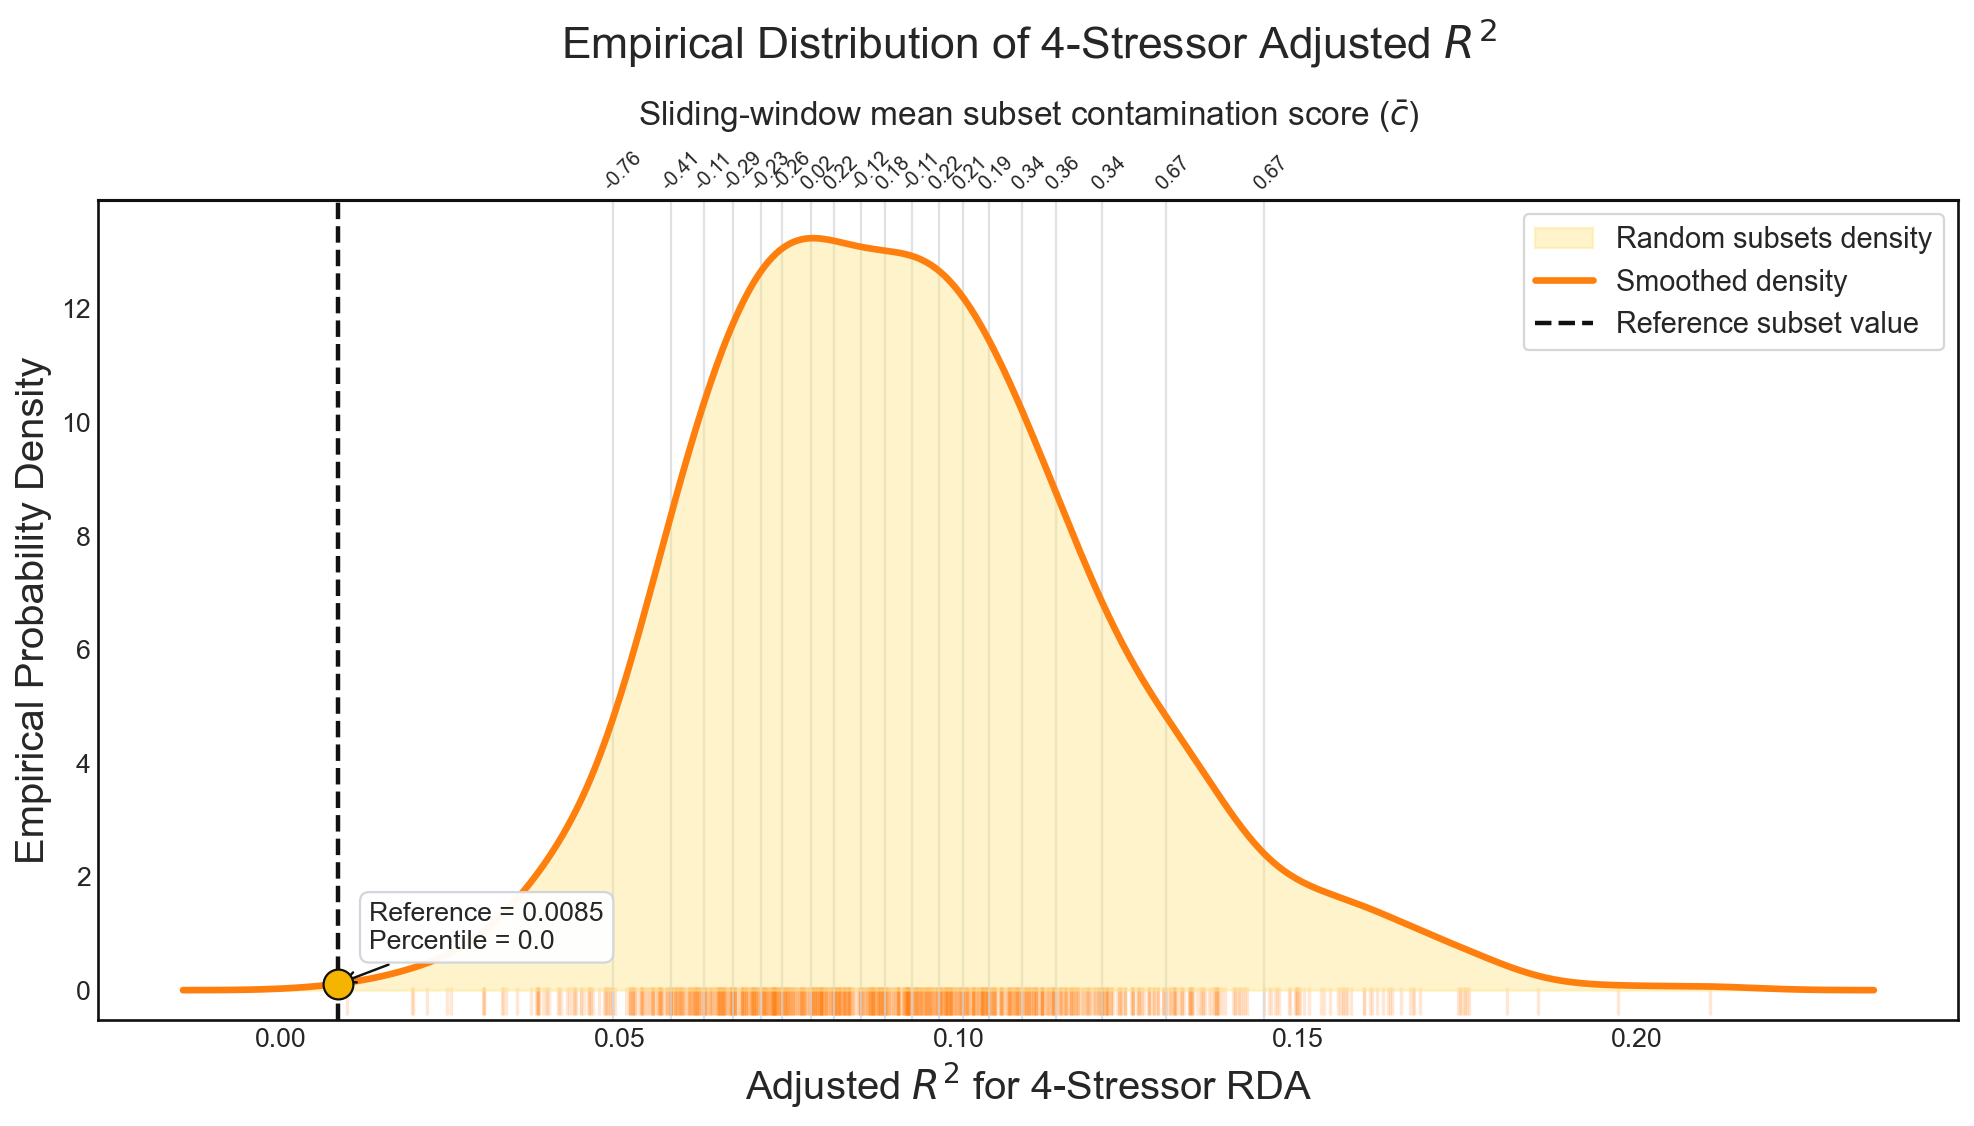

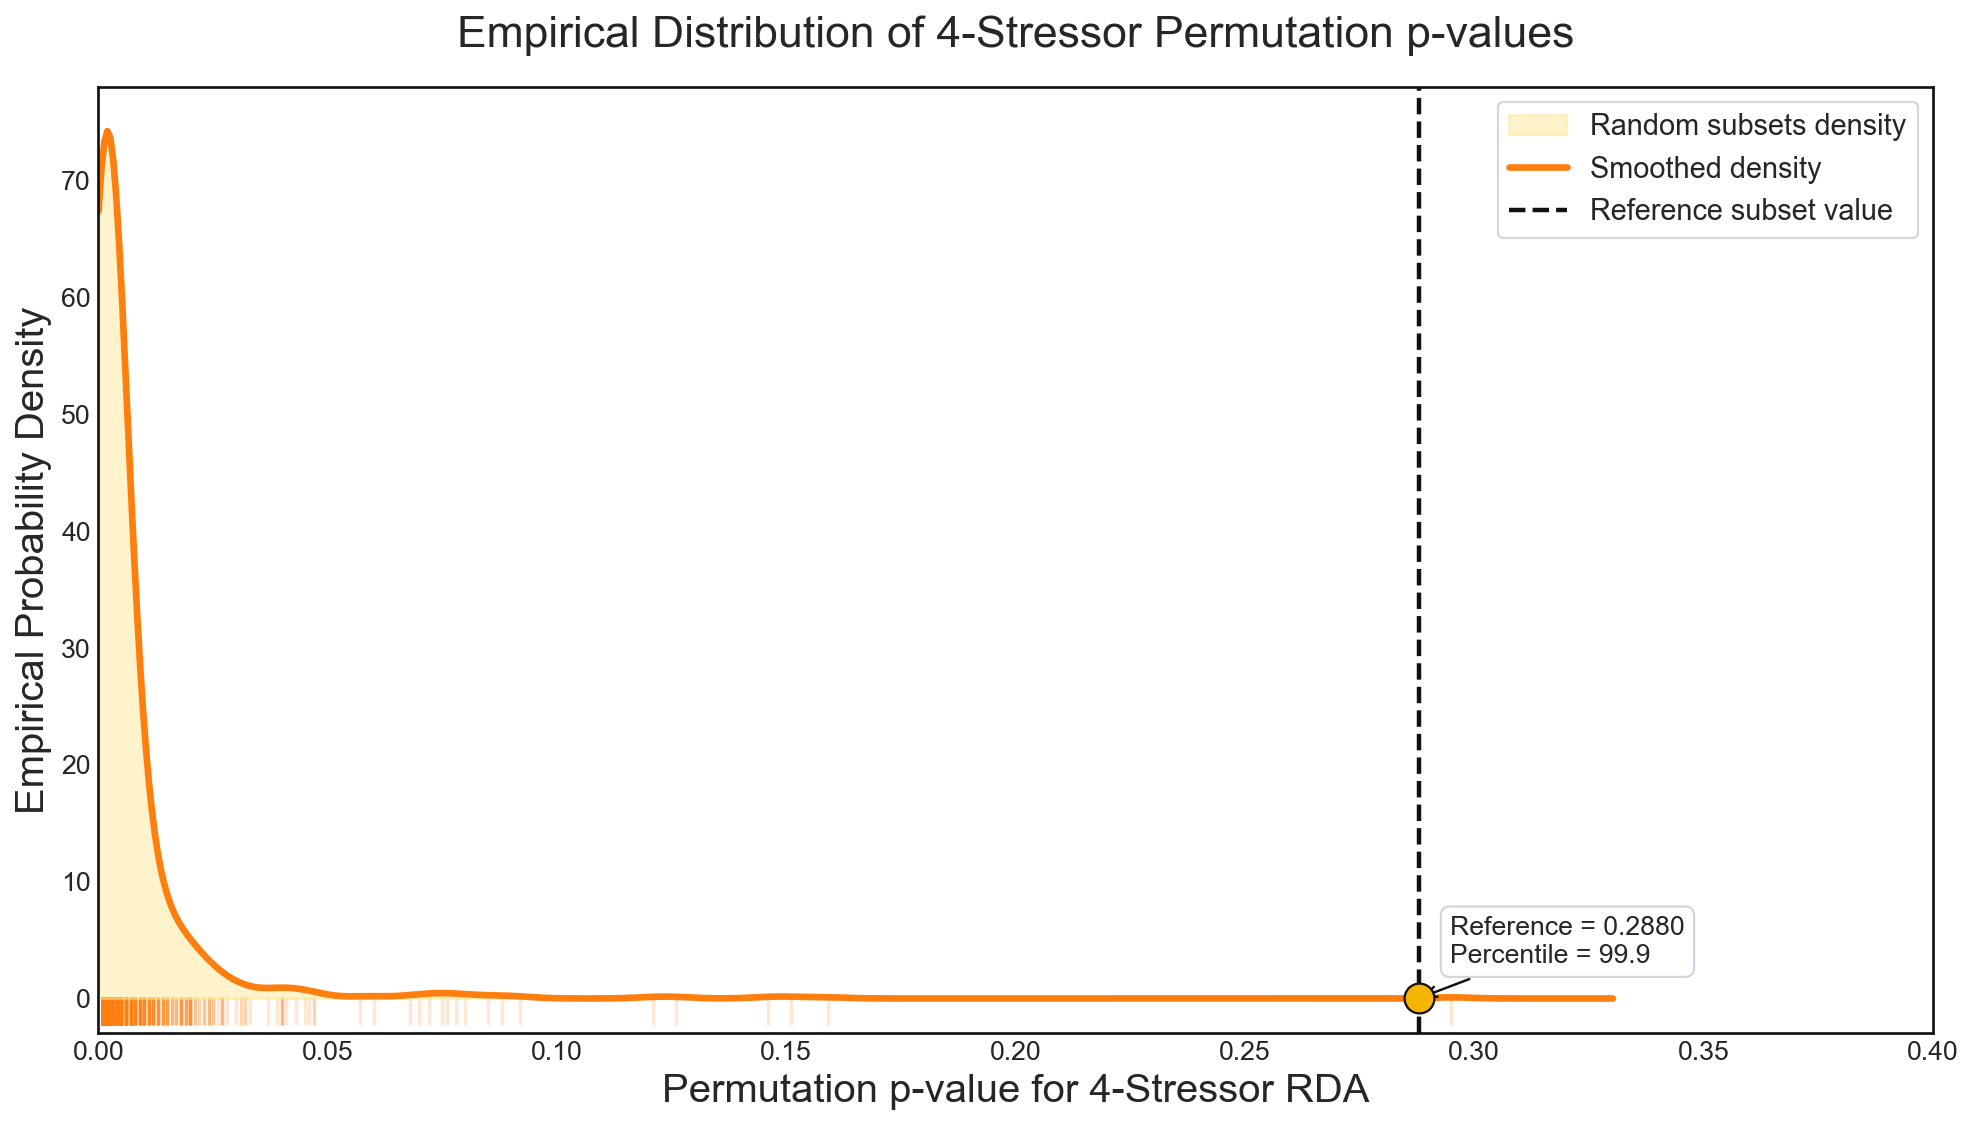

Saved adjusted-R² distribution figure to: ../figures/ch2_fw2_empirical_distribution_adj_R2.png
Saved p-value distribution figure to: ../figures/ch2_fw2_empirical_distribution_p_value.png


In [112]:
set_plot_theme()

adj_r2_figure_path = FIGURE_DIR / "ch2_fw2_empirical_distribution_adj_R2.png"
p_value_figure_path = FIGURE_DIR / "ch2_fw2_empirical_distribution_p_value.png"

fig_adj_r2, ax_adj_r2 = plot_empirical_distribution(
    random_values=random_results["adj_R2_str"],
    reference_value=float(reference_result["adj_R2_str"]),
    x_label=r"Adjusted $R^2$ for 4-Stressor RDA",
    title="Empirical Distribution of 4-Stressor Adjusted $R^2$",
    curve_color="#ff7f0e",
    fill_color="#fde68a",
    reference_color="#f4b400",
    top_axis_mode="sliding_contamination",
    top_axis_values=random_results["average_c"],
    output_path=adj_r2_figure_path,
)

fig_p_value, ax_p_value = plot_empirical_distribution(
    random_values=random_results["p_value_stressor"],
    reference_value=float(reference_result["p_value_stressor"]),
    x_label="Permutation p-value for 4-Stressor RDA",
    title="Empirical Distribution of 4-Stressor Permutation p-values",
    curve_color="#ff7f0e",
    fill_color="#fde68a",
    reference_color="#f4b400",
    x_bounds=(0.0, 0.4),
    output_path=p_value_figure_path,
)

print(f"Saved adjusted-R² distribution figure to: {adj_r2_figure_path}")
print(f"Saved p-value distribution figure to: {p_value_figure_path}")

# Optional extension: compare multiple subset sizes

This section is disabled by default because it can be computationally expensive. Set `RUN_EXTENSION = True` to run the same RDA resampling comparison for additional values of `m`.

In [113]:
RUN_EXTENSION = False

EXTENSION_M_VALUES = [60, 150, 250]
EXTENSION_RANDOM_SUBSETS = N_RANDOM_SUBSETS
EXTENSION_PERMUTATIONS = PERMUTATIONS

if RUN_EXTENSION:
    extension_start_time = perf_counter()
    extension_result_frames = []

    for m_index, m_value in enumerate(EXTENSION_M_VALUES, start=1):
        m_start_time = perf_counter()
        extension_result_frames.append(
            run_ranked_subset_rda_for_m(
                m_value=m_value,
                B_value=EXTENSION_RANDOM_SUBSETS,
                permutations_value=EXTENSION_PERMUTATIONS,
                base_seed=RANDOM_STATE + m_value,
                stressor_table=S_c,
                stressor_table_z=S_c_z,
                taxa_table=T_with_site_id,
                score_lookup=score_lookup,
            )
        )
        m_elapsed_seconds = perf_counter() - m_start_time
        total_elapsed_seconds = perf_counter() - extension_start_time
        print(
            f"Finished m={m_value} ({m_index}/{len(EXTENSION_M_VALUES)}) "
            f"in {m_elapsed_seconds:.1f}s; total elapsed {total_elapsed_seconds / 60:.1f} min"
        )

    extension_rda_results = pd.concat(extension_result_frames, ignore_index=True)
    extension_m_summary = summarize_extension_results(extension_rda_results, EXTENSION_M_VALUES)

    extension_figure_path = FIGURE_DIR / "ch2_fw2_extension_adj_R2_by_m.png"

    plot_adj_r2_comparison(
        results_df=extension_rda_results,
        m_values=EXTENSION_M_VALUES,
        output_path=extension_figure_path,
    )

    extension_elapsed_minutes = (perf_counter() - extension_start_time) / 60.0
    print(f"Extension run completed in {extension_elapsed_minutes:.1f} minutes")
    print(f"Saved extension figure to: {extension_figure_path}")
    display(extension_m_summary)
else:
    print("Extension skipped. Set RUN_EXTENSION = True to run the multi-m sensitivity comparison.")

Extension skipped. Set RUN_EXTENSION = True to run the multi-m sensitivity comparison.


# Execution summary

After a complete run, this notebook should produce:

```text
../results/ch2_fw2_resampling_rda_results.xlsx
../artifacts/A2_least_polluted_IDs.xlsx
../figures/ch2_fw2_empirical_distribution_adj_R2.png
../figures/ch2_fw2_empirical_distribution_p_value.png
# Optional extension outputs
../figures/ch2_fw2_extension_adj_R2_by_m.png
```